In [100]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
from sklearn.feature_selection import mutual_info_classif, VarianceThreshold

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [101]:
df = pd.read_csv("heart_attack_prediction_india.csv")

# Drop ID
df.drop("Patient_ID", axis=1, inplace=True)

In [102]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].str.strip().str.lower()

df = pd.get_dummies(df, drop_first=True)

# Fix column names (important for LightGBM)
df.columns = df.columns.str.replace(' ', '_')

In [106]:
# ---- Core interactions ----
df['BP_Risk'] = df['Systolic_BP'] + df['Diastolic_BP']
df['Lipid_Risk'] = df['LDL_Level'] + df['Triglyceride_Level']
df['Chol_Ratio'] = df['LDL_Level'] / (df['HDL_Level'] + 1)

# ---- Lifestyle + medical ----
df['Lifestyle_Risk'] = (
    df['Alcohol_Consumption'] +
    df['Smoking'] -
    df['Physical_Activity']
)

df['Medical_Risk'] = (
    df['Diabetes'] +
    df['Hypertension'] +
    df['Obesity']
)

# ---- Strong combined signal ----
df['Cardio_Risk'] = (
    df['BP_Risk'] +
    df['Lipid_Risk'] +
    df['Age']
)


In [107]:
leakage_cols = ['Emergency_Response_Time']  # critical
df.drop(columns=leakage_cols, errors='ignore', inplace=True)

In [108]:
X = df.drop("Heart_Attack_Risk", axis=1)
y = df["Heart_Attack_Risk"]

In [109]:
selector = VarianceThreshold(threshold=0.01)
X_var = pd.DataFrame(selector.fit_transform(X), columns=X.columns[selector.get_support()])

In [110]:
mi = mutual_info_classif(X_var, y, random_state=42)
mi_series = pd.Series(mi, index=X_var.columns).sort_values(ascending=False)

# KEEP TOP FEATURES instead of thresholding
top_k = 30   # 🔥 key idea: fixed number instead of threshold
selected_features = mi_series.head(top_k).index

X = X_var[selected_features]

In [111]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (6400, 30) Val: (1600, 30) Test: (2000, 30)


In [112]:
model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=10,
    subsample=0.9,
    colsample_bytree=0.9,
    class_weight='balanced',
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(50),
        lgb.log_evaluation(100)
    ]
)

[LightGBM] [Info] Number of positive: 1925, number of negative: 4475
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000870 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1187
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.688397
Early stopping, best iteration is:
[125]	valid_0's binary_logloss: 0.685728


LGBMClassifier(class_weight='balanced', colsample_bytree=0.9,
               learning_rate=0.05, min_child_samples=10, n_estimators=500,
               random_state=42, subsample=0.9)

In [113]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.69      0.68      0.68      1399
           1       0.29      0.30      0.30       601

    accuracy                           0.56      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.57      0.56      0.57      2000

ROC-AUC: 0.48695467049794305


In [114]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    lgb.LGBMClassifier(**model.get_params()),
    X, y,
    cv=cv,
    scoring='roc_auc'
)

print(f"CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

[LightGBM] [Info] Number of positive: 2406, number of negative: 5594
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001036 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1187
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 2406, number of negative: 5594
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001100 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1187
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 30
[LightGBM] [Info] [binary:

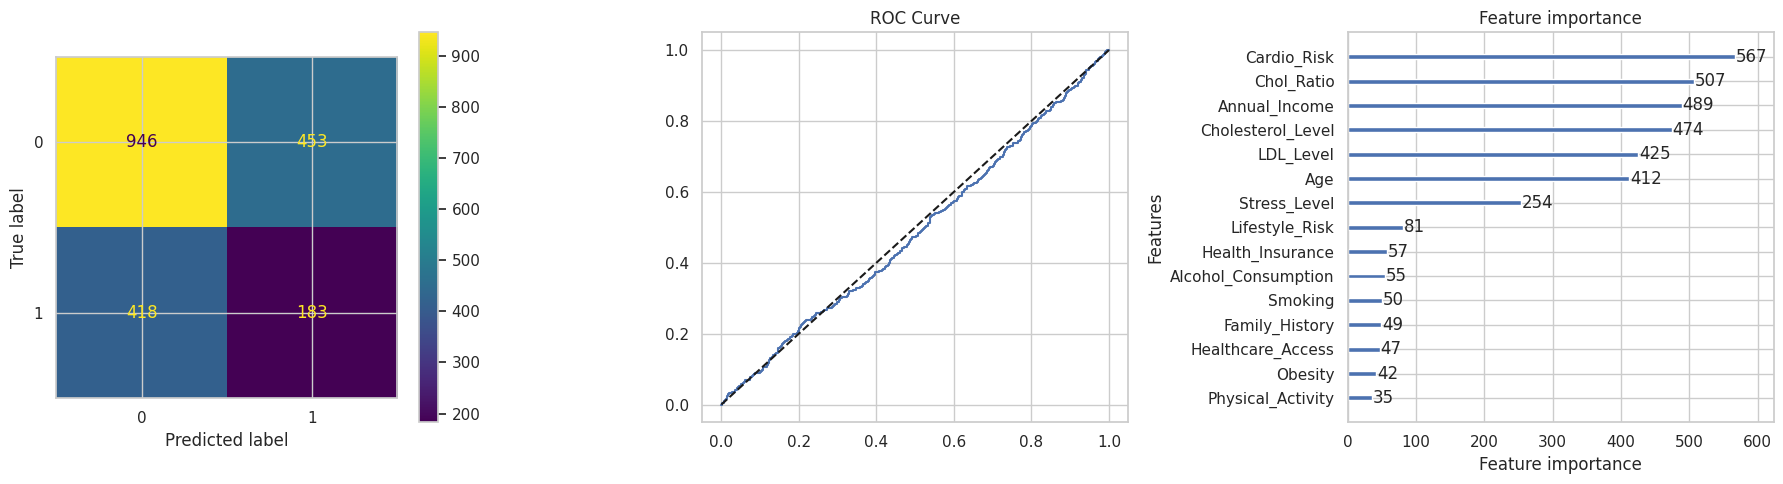

In [115]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0])

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr)
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title("ROC Curve")

# Feature importance
lgb.plot_importance(model, ax=axes[2], max_num_features=15)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


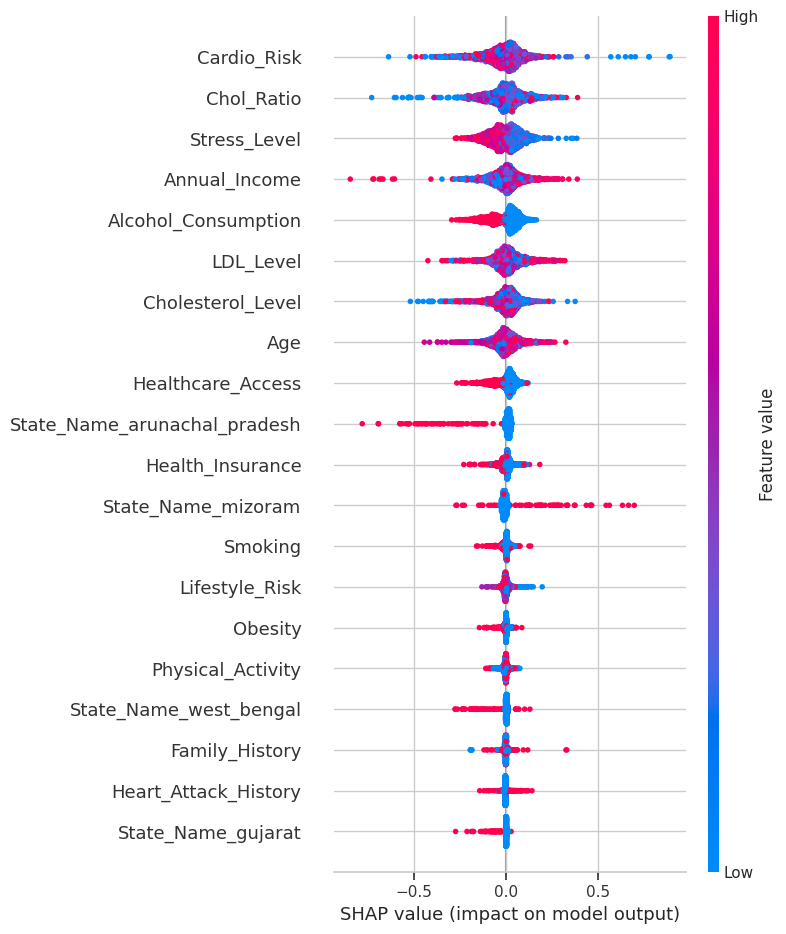

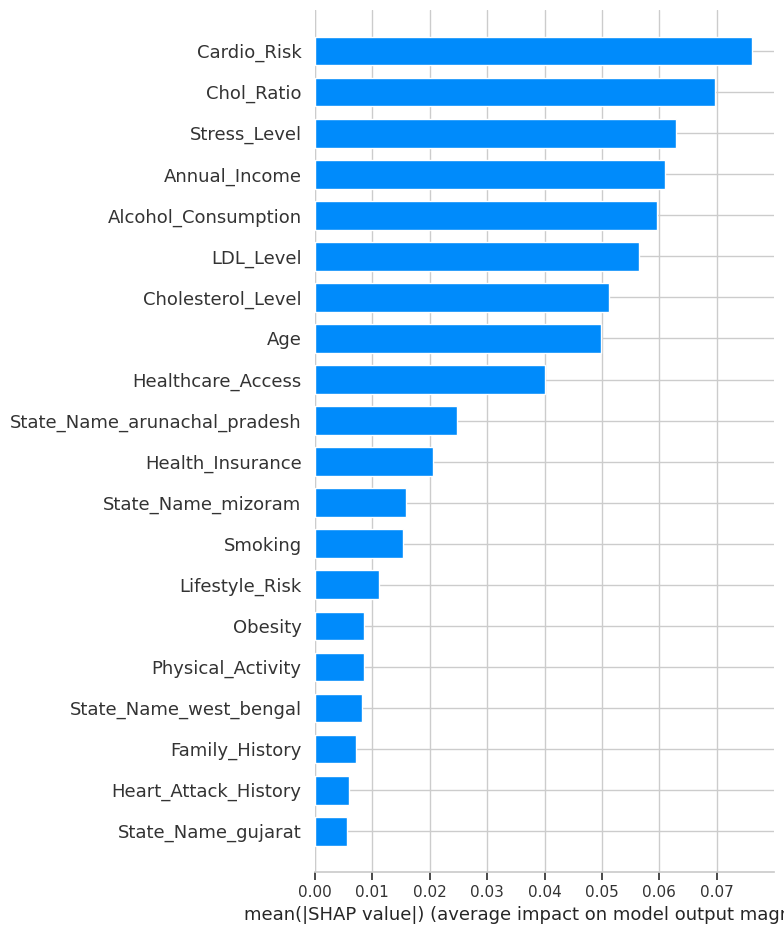

In [116]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary
shap.summary_plot(shap_values, X_test)

# Bar importance
shap.summary_plot(shap_values, X_test, plot_type="bar")